# Fifa 21 players dataset analysis

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [173]:
df = pd.read_csv("../data/players_21.csv")

df_clean = df[df['value_eur'] > 0]

In [174]:
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,33,1987-06-24,170,72,Argentina,FC Barcelona,...,66+3,65+3,65+3,65+3,66+3,62+3,52+3,52+3,52+3,62+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,35,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,54+3,54+3,54+3,61+3
2,200389,https://sofifa.com/player/200389/jan-oblak/210002,J. Oblak,Jan Oblak,27,1993-01-07,188,87,Slovenia,Atlético Madrid,...,32+3,36+3,36+3,36+3,32+3,32+3,33+3,33+3,33+3,32+3
3,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,31,1988-08-21,184,80,Poland,FC Bayern München,...,64+3,65+3,65+3,65+3,64+3,61+3,60+3,60+3,60+3,61+3
4,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,28,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,67+3,62+3,62+3,62+3,67+3,62+3,49+3,49+3,49+3,62+3


## Dataprocessing

Bar graph with the countries with the highest average overall rating

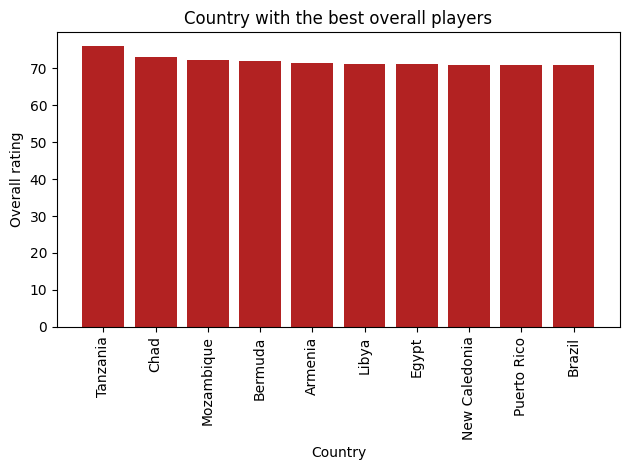

In [200]:
overall_by_nation = df.groupby('nationality')['overall'].mean().sort_values(ascending=False).head(10)

plt.title("Country with the best overall players")
plt.xlabel("Country")
plt.ylabel("Overall rating")

plt.bar(overall_by_nation.index, overall_by_nation.values, color='firebrick')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Graph with the overall rating by the age

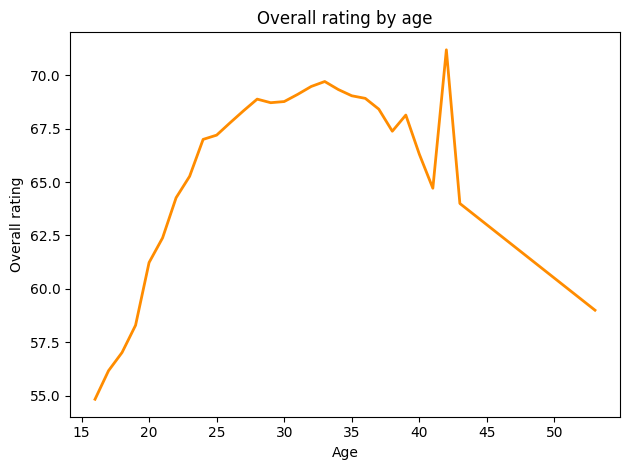

In [219]:
overall_by_age = df.groupby('age')['overall'].mean()

plt.title("Overall rating by age")
plt.xlabel("Age")
plt.ylabel("Overall rating")

plt.plot(overall_by_age.index, overall_by_age.values, color='darkorange', linewidth=2)

plt.tight_layout()
plt.show()

Scatter graph with the market value vs the overall rating 

Line graph with the calculated average

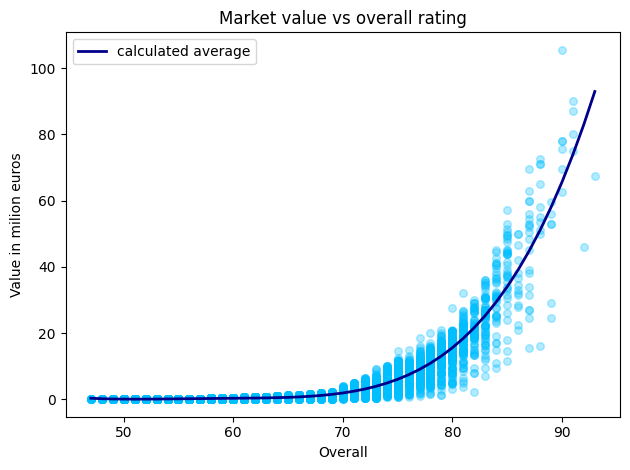

In [ ]:
plt.title("Market value vs overall rating")
plt.xlabel("Overall")
plt.ylabel("Value in million euros")

z = np.polyfit(df_clean['overall'], df_clean['value_eur'] / 1_000_000, 4)
p = np.poly1d(z)


plt.scatter(df_clean['overall'], (df_clean['value_eur'] / 1_000_000), color="deepskyblue", alpha=0.3, s=30)
plt.plot(sorted(df_clean['overall']), p(sorted(df_clean['overall'])), label='calculated average', color='darkblue', linewidth=2)

plt.legend()
plt.tight_layout()
plt.show()

The highest rated players with their info

In [178]:
top10_overall = df[['short_name', 'club_name', 'nationality', 'overall']].sort_values('overall', ascending=False).head(12)
print(top10_overall)

           short_name            club_name  nationality  overall
0            L. Messi         FC Barcelona    Argentina       93
1   Cristiano Ronaldo             Juventus     Portugal       92
2            J. Oblak      Atlético Madrid     Slovenia       91
3      R. Lewandowski    FC Bayern München       Poland       91
4           Neymar Jr  Paris Saint-Germain       Brazil       91
5        K. De Bruyne      Manchester City      Belgium       91
6           K. Mbappé  Paris Saint-Germain       France       90
7       M. ter Stegen         FC Barcelona      Germany       90
8         V. van Dijk            Liverpool  Netherlands       90
9             Alisson            Liverpool       Brazil       90
10            S. Mané            Liverpool      Senegal       90
11           M. Salah            Liverpool        Egypt       90


Bar graph with the clubs with the highest average overall rating

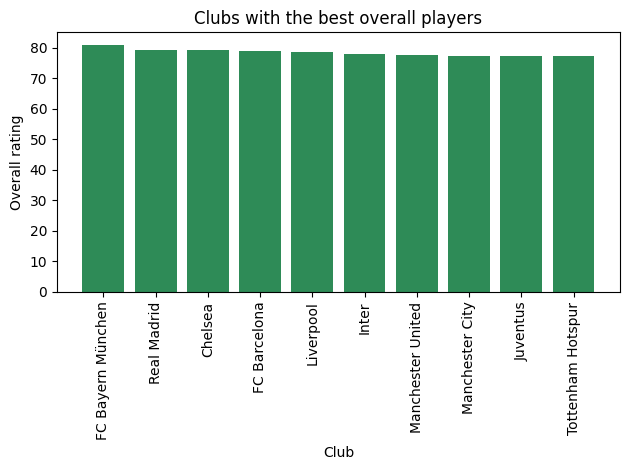

In [226]:
overall_by_club = df.groupby('club_name')['overall'].mean().sort_values(ascending=False).head(10)

plt.title("Clubs with the best overall players")
plt.xlabel("Club")
plt.ylabel("Overall rating")

plt.bar(overall_by_club.index, overall_by_club.values, color='seagreen')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()